In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, classification_report, precision_score,
                             recall_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB, ComplementNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Classification

## First Target (Binary Class Classification): isMovie

### Retrieving the clean and scaled datasets (train and test) from the Data Understanding step

In [64]:
sns.set(style="whitegrid")
sns.set_theme(palette='viridis')
# Load the preprocessed data
data_train = pd.read_csv('data/output/02_data_understanding/clean_normalized_data_train.csv')
data_test = pd.read_csv('data/output/02_data_understanding/clean_normalized_data_test.csv')

# Supponendo che 'titleType' sia già stato etichettato tramite Label Encoding
data_train['titleType'] = data_train['titleType'].fillna(8.0)
data_test['titleType'] = data_test['titleType'].fillna(8.0)

data_train.info()
data_train.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13943 entries, 0 to 13942
Columns: 205 entries, originalTitle to ZW
dtypes: float64(8), int64(196), object(1)
memory usage: 21.8+ MB


,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,numRegions,userReviewsTotal,...,VC,VE,VN,XKV,XWG,XYU,YUCS,ZA,ZM,ZW
0,Neogenic Nightmare Chapter 3: Hydro-Man,8,1995,0.500000,6.659294,3.091042,0.693147,2,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,Idealnaya para,6,1992,1.500000,3.663562,3.218876,0.000000,1,0.693147,0.693147,...,0,0,0,0,0,0,0,0,0,0
2,MasterChef Celebrity México,6,2021,0.500000,2.772589,4.043051,0.000000,0,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
3,Lightdance,9,1995,0.566667,2.708050,0.000000,0.000000,7,0.693147,0.693147,...,0,0,0,0,0,0,0,0,0,0
4,"Kiss, Kiss Bang, Bang",8,1995,0.750000,4.574711,4.709530,0.000000,2,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
5,Estrela de Oito Pontas,8,1996,0.200000,2.564949,1.098612,0.000000,8,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
6,JJBA Mangabridged: Phantom Blood 2 of 2,9,2017,0.733333,3.526361,1.791759,0.000000,3,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
7,Golubaya chashka,7,1965,1.000000,3.218876,3.610918,0.000000,1,1.386294,0.000000,...,0,0,0,0,0,0,0,0,0,0
8,The Formula,3,2014,1.500000,6.637258,4.955827,0.693147,1,1.791759,1.609438,...,0,0,0,0,0,0,0,0,0,0
9,Kako ubiv svetec,7,2004,1.366667,5.777652,4.442651,0.693147,1,1.945910,1.098612,...,0,0,0,0,0,0,0,0,0,0


In [65]:
# Creation of the new columns isMovie, that will be used as target
data_train['isMovie'] = (data_train['titleType'] == 1).astype(int)
data_test['isMovie'] = (data_test['titleType'] == 1).astype(int)

selected_columns = ['runtimeMinutes', 'numVotes', 'rating', 'totalCredits', 'totalMedia', 'criticReviewsTotal', 'isMovie',
                    'Adult', 'numRegions', 'NumberOfCountryoforigin', 'totalRecognitions', 'NumberOfGenres',
                    'startYearDecade', 'startYear']

df_selected = data_train[selected_columns]

# Step 3: Calculate the correlation of 'isMovie' with each of the selected columns
correlation_isMovie = df_selected.corr()['isMovie'].drop('isMovie')  # Dropping 'isMovie' from the result

# Step 6: Print correlation values (optional)
print(correlation_isMovie)

runtimeMinutes             0.758112
numVotes                   0.211888
rating                    -0.304356
totalCredits               0.076985
totalMedia                 0.286275
criticReviewsTotal         0.363942
Adult                     -0.026114
numRegions                 0.519353
NumberOfCountryoforigin    0.128373
totalRecognitions          0.206226
NumberOfGenres            -0.176833
startYearDecade           -0.157572
startYear                 -0.160792
Name: isMovie, dtype: float64


Percentage distribution of 'isMovie' (combined train and test):
isMovie
0    63.038097
1    36.961903
Name: proportion, dtype: float64


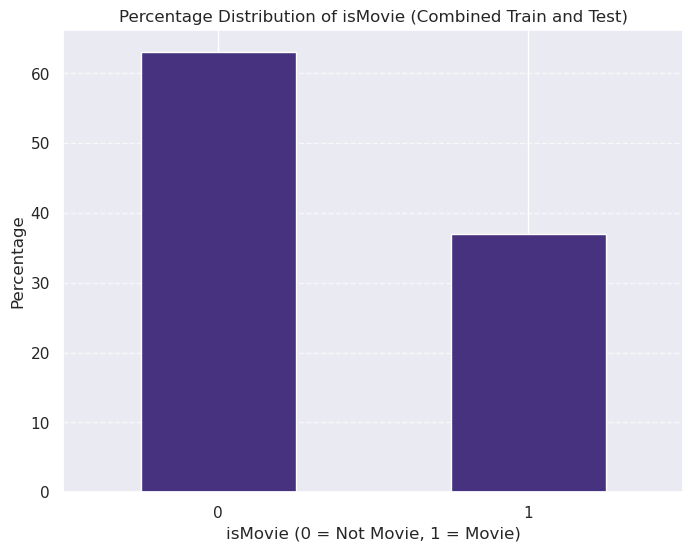

In [ ]:
# Combine train and test datasets for analysis
combined_data = pd.concat([data_train, data_test])

# Calculate the percentage distribution of 'isMovie'
percentages_combined = combined_data['isMovie'].value_counts(normalize=True) * 100

# Print the percentages
print("Percentage distribution of 'isMovie' (combined train and test):")
print(percentages_combined)

plt.figure(figsize=(4, 3))
percentages_combined.plot(kind='bar')
plt.title('Percentage Distribution of isMovie (Combined Train and Test)')
plt.xlabel('isMovie (0 = Not Movie, 1 = Movie)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## KNN

In [67]:
# List of columns to include for k-NN
# After a research, this selection of columns provided the best result
selected_columns = [
    'runtimeMinutes', 'numVotes', 'totalCredits',
    'criticReviewsTotal', 'Adult', 'numRegions'
]

# Define features and target
X_train_knn = data_train[selected_columns]
y_train_knn = data_train['isMovie']

X_test_knn = data_test[selected_columns]
y_test_knn = data_test['isMovie']

X_train_knn.head()

,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,Adult,numRegions
0,0.500000,6.659294,3.091042,0.693147,0,0.693147
1,1.500000,3.663562,3.218876,0.000000,0,0.693147
2,0.500000,2.772589,4.043051,0.000000,0,0.693147
3,0.566667,2.708050,0.000000,0.000000,0,0.693147
4,0.750000,4.574711,4.709530,0.000000,0,0.693147


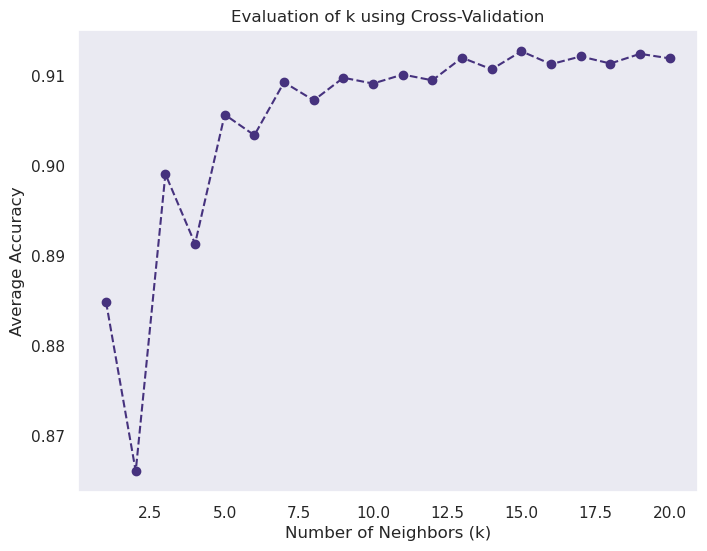

In [68]:
# Search for the best k value
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_knn, y_train_knn, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot to visualize k search
plt.figure(figsize=(8, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='--')
plt.title('Evaluation of k using Cross-Validation')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average Accuracy')
plt.grid()
plt.show()

In [69]:
# Best k value
best_k = k_values[np.argmax(cv_scores)]
print(f"Best k value: {best_k}")

Best k value: 15


In [70]:
# Train the model with the best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_knn, y_train_knn)

y_pred = knn.predict(X_test_knn)

# Evaluate performance metrics
accuracy = accuracy_score(y_test_knn, y_pred)
precision = precision_score(y_test_knn, y_pred)
recall = recall_score(y_test_knn, y_pred)
f1 = f1_score(y_test_knn, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.91
Precision: 0.84
Recall: 0.93
F1 Score: 0.88


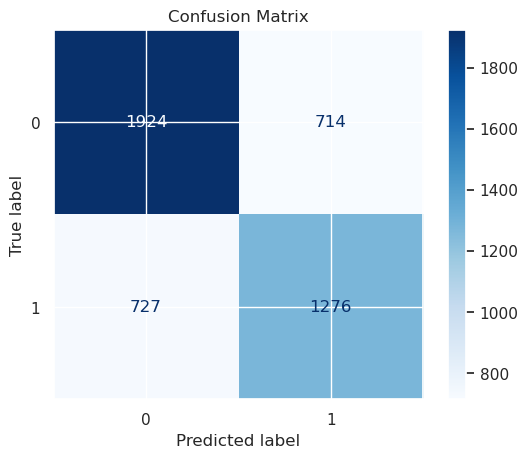

In [112]:
# Confusion matrix
cm = confusion_matrix(y_test_knn, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

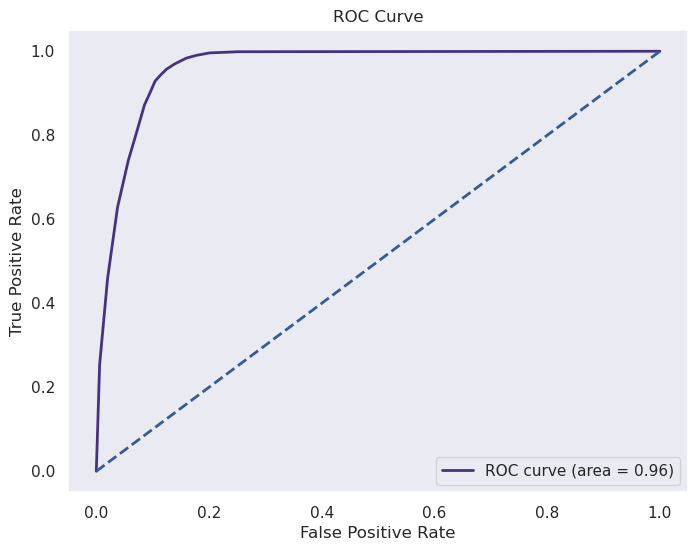

In [72]:
# ROC curve
y_test_binarized = label_binarize(y_test_knn, classes=[0, 1])
y_pred_proba = knn.predict_proba(X_test_knn)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_binarized, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

## Naive Bayes

### We'll use the Gaussian Naive Bayes Classifier, as the columns have been normalized.

In [73]:
# List of columns to include for Gaussian Naive Bayes
# After a research, this selection of columns provided the best result
selected_columns = [
    'rating', 'runtimeMinutes', 'Adult', 'totalCredits'
]

# Define features and target
X_train_gnb = data_train[selected_columns]
y_train_gnb = data_train['isMovie']

X_test_gnb = data_test[selected_columns]
y_test_gnb = data_test['isMovie']

In [74]:
# after having tried with Gaussian, Complement and Multinomial, Gaussian gave the best results
gnb = GaussianNB()
gnb.fit(X_train_gnb, y_train_gnb)

# Make predictions on the test set
y_pred = gnb.predict(X_test_gnb)

accuracy = accuracy_score(y_test_gnb, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_gnb, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_gnb, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.8961

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      2895
           1       0.84      0.89      0.87      1746

    accuracy                           0.90      4641
   macro avg       0.89      0.90      0.89      4641
weighted avg       0.90      0.90      0.90      4641


Confusion Matrix:
[[2598  297]
 [ 185 1561]]


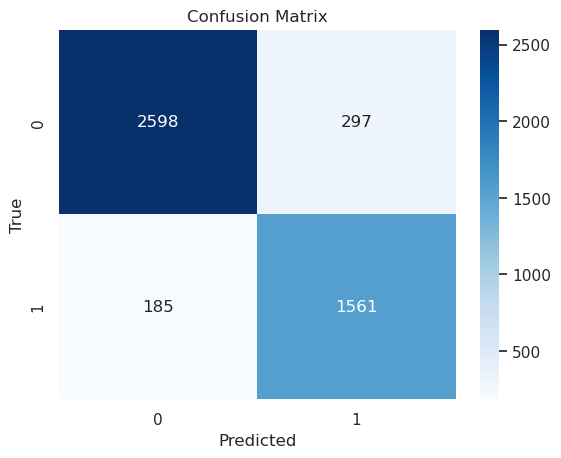

In [ ]:
# Visualize Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', xticklabels=gnb.classes_, yticklabels=gnb.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

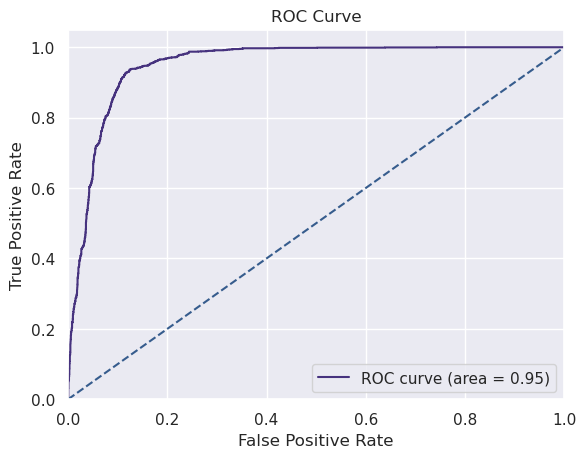

In [76]:
# ROC Curve
# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test_gnb, gnb.predict_proba(X_test_gnb)[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line for random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## Decision Trees

In [77]:
# For Decision Trees, we'll use the not normalized datasets
not_normalized_data_train = pd.read_csv('data/output/02_data_understanding/clean_data_train.csv')
not_normalized_data_test = pd.read_csv('data/output/02_data_understanding/clean_data_test.csv')

# Supponendo che 'titleType' sia già stato etichettato tramite Label Encoding
not_normalized_data_train['titleType'] = not_normalized_data_train['titleType'].fillna(8.0)
not_normalized_data_test['titleType'] = not_normalized_data_test['titleType'].fillna(8.0)

# Verifica se i NaN sono stati sostituiti correttamente
print(data_train['titleType'].isna().sum())  # Dovrebbe stampare 0
print(data_test['titleType'].isna().sum())  # Dovrebbe stampare 0

# Creation of the new columns isMovie, that will be used as target
not_normalized_data_train['isMovie'] = (not_normalized_data_train['titleType'] == 1).astype(int)
not_normalized_data_test['isMovie'] = (not_normalized_data_test['titleType'] == 1).astype(int)

# Define features and target
X_train_dt = not_normalized_data_train.drop(columns=['originalTitle', 'titleType', 'isMovie'])
y_train_dt = not_normalized_data_train['isMovie']

X_test_dt = not_normalized_data_test.drop(columns=['originalTitle', 'titleType', 'isMovie'])
y_test_dt = not_normalized_data_test['isMovie']

# Base model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_dt, y_train_dt)

# Predictions
y_pred = dt.predict(X_test_dt)

# Score
print("Accuracy:", accuracy_score(y_test_dt, y_pred))
print("Classification Report:\n", classification_report(y_test_dt, y_pred)) 

0
0
Accuracy: 0.9135962077138547
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93      2895
           1       0.87      0.90      0.89      1746

    accuracy                           0.91      4641
   macro avg       0.91      0.91      0.91      4641
weighted avg       0.91      0.91      0.91      4641



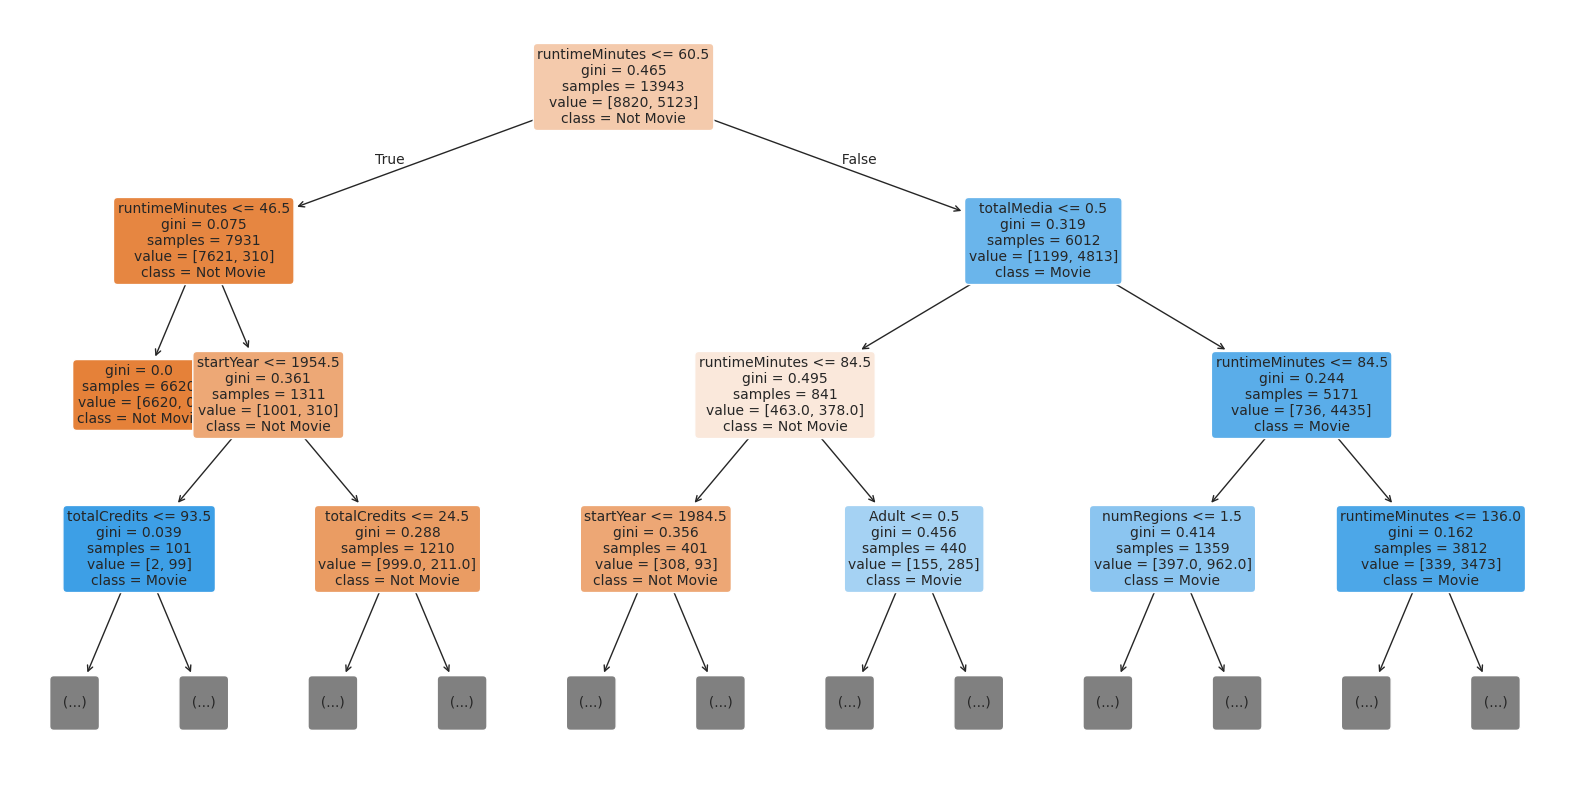

In [78]:
plt.figure(figsize=(20, 10))
sns.set_theme(palette='viridis')
plot_tree(dt, feature_names=X_train_dt.columns, class_names=['Not Movie', 'Movie'], max_depth=3, fontsize=10, filled=True, rounded=True)
plt.show()

In [79]:
# Hyperparameters
param_grid = {
    'criterion': ['gini', 'entropy'],         # Funzione di split
    'max_depth': [3, 5, 10, None],            # Profondità massima
    'min_samples_split': [2, 5, 10],          # Split minimo
    'min_samples_leaf': [1, 2, 4],            # Foglie minime
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1)

grid_search.fit(X_train_dt, y_train_dt)

# Migliori parametri e valutazione
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test_dt)

print("Optimized Accuracy:", accuracy_score(y_test_dt, y_pred_best))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Optimized Accuracy: 0.9161818573583279


Optimized Accuracy: 0.5203619909502263
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.57      0.57      2656
           1       0.44      0.46      0.45      1985

    accuracy                           0.52      4641
   macro avg       0.51      0.51      0.51      4641
weighted avg       0.52      0.52      0.52      4641



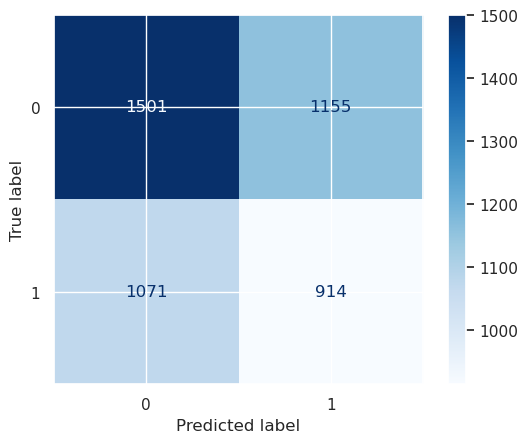

In [111]:
# Define the Decision Tree model with optimized parameters
dt_optimized = DecisionTreeClassifier(
    criterion='entropy',           # Split criterion (information gain)
    max_depth=10,                  # Maximum depth of the tree
    min_samples_leaf=4,            # Minimum number of samples required for a leaf node
    min_samples_split=10,           # Minimum number of samples required to split a node
    random_state=42,                # Ensures reproducibility of results
    ccp_alpha= 0.00018279905008586903
)

# Train the model on the training dataset
dt_optimized.fit(X_train_dt, y_train_dt)

# Make predictions on the test dataset
y_pred_optimized = dt_optimized.predict(X_test_dt)

# Evaluate the model's performance
print("Optimized Accuracy:", accuracy_score(y_test_dt, y_pred_optimized))  # Output overall accuracy
print("Classification Report:\n", classification_report(y_test_dt, y_pred_optimized))  # Detailed metrics

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test_dt, y_pred_optimized)

# Display the confusion matrix as a heatmap
ConfusionMatrixDisplay(conf_matrix, display_labels=dt_optimized.classes_).plot(cmap=plt.cm.Blues)

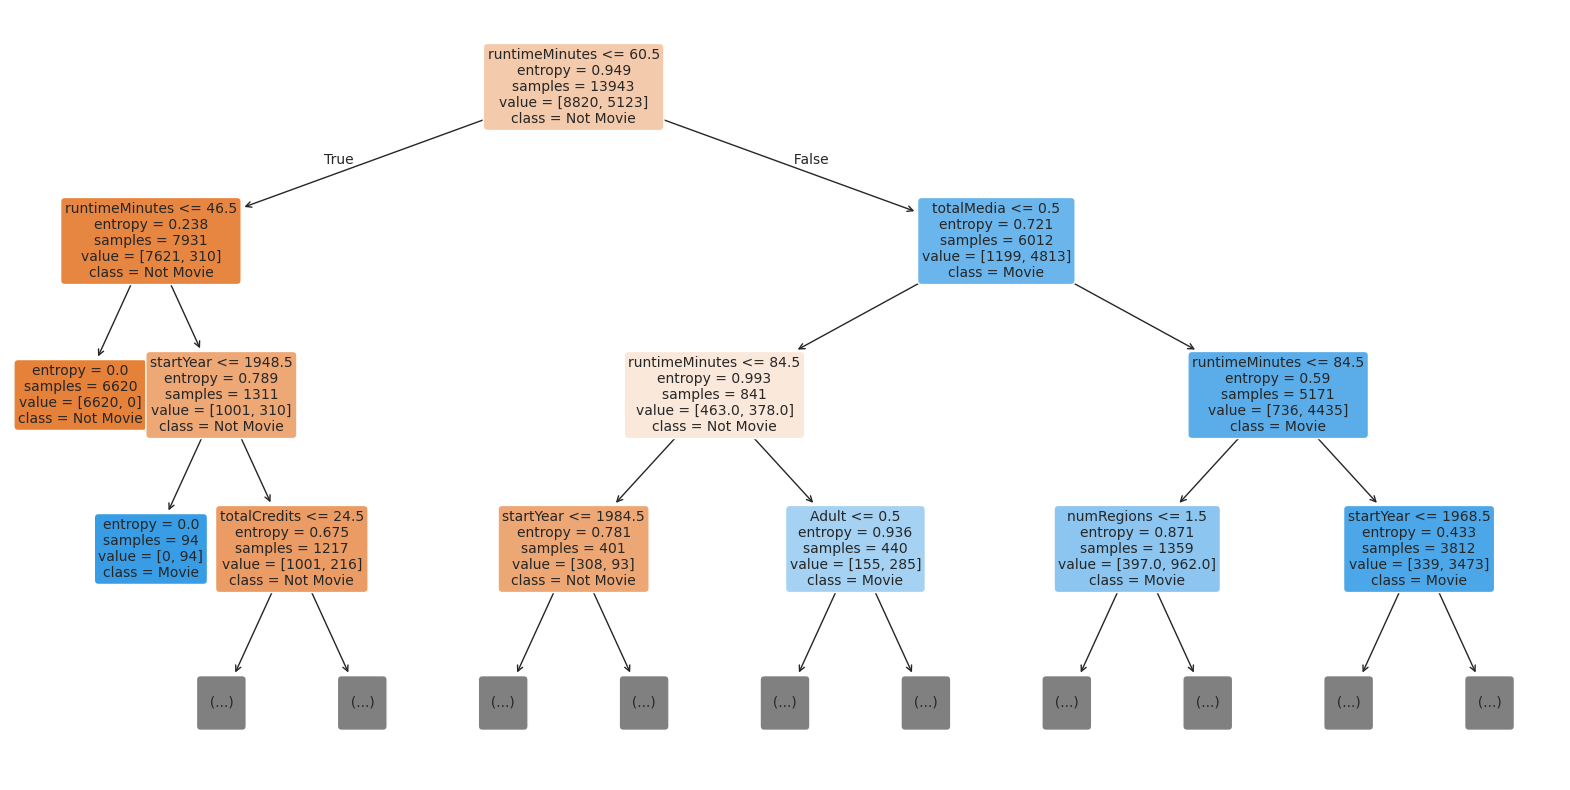

In [81]:
plt.figure(figsize=(20, 10))
plot_tree(dt_optimized, feature_names=X_train_dt.columns, class_names=['Not Movie', 'Movie'], filled=True, rounded=True, max_depth=3, fontsize=10)
plt.show()

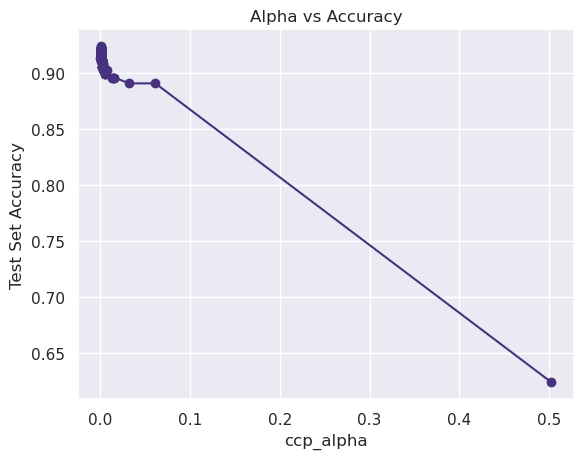

Best value of alpha: 0.000183245462437796
Its Accuracy: 0.92


In [82]:
# Tuning of Alpha
path = dt_optimized.cost_complexity_pruning_path(X_train_dt, y_train_dt)
alphas = path.ccp_alphas  # Serie di valori di α
scores = []

# Testare ogni valore di α
best_alpha = None
best_score = -1

for alpha in alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train_dt, y_train_dt)
    score = clf.score(X_test_dt, y_test_dt)
    scores.append(score)
    
    # Identificare il miglior alpha
    if score > best_score:
        best_score = score
        best_alpha = alpha

# Visualizzare l'accuratezza in funzione di α
plt.plot(alphas, scores, marker='o')
plt.xlabel('ccp_alpha')
plt.ylabel('Test Set Accuracy')
plt.title('Alpha vs Accuracy')
plt.show()

# Stampare il miglior valore di alpha e l'accuratezza corrispondente
print(f"Best value of alpha: {best_alpha}")
print(f"Its Accuracy: {best_score:.2f}")

# The value of alpha was inserted above


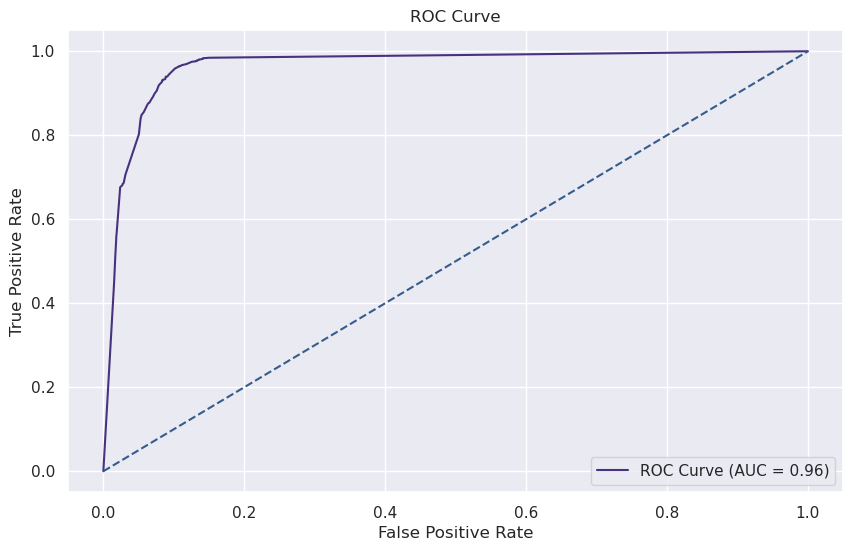

In [83]:
y_pred_proba = dt_optimized.predict_proba(X_test_dt)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_dt, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [84]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, classification_report, precision_score,
                             recall_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB, ComplementNB, MultinomialNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

## Target: Rating>8

In [85]:
# Load the preprocessed data
data_train = pd.read_csv('data/output/02_data_understanding/clean_normalized_data_train.csv')
data_test = pd.read_csv('data/output/02_data_understanding/clean_normalized_data_test.csv')

data_train['titleType'] = data_train['titleType'].fillna(8.0)
data_test['titleType'] = data_test['titleType'].fillna(8.0)

data_train.info()
data_train.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13943 entries, 0 to 13942
Columns: 205 entries, originalTitle to ZW
dtypes: float64(8), int64(196), object(1)
memory usage: 21.8+ MB


,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,numRegions,userReviewsTotal,...,VC,VE,VN,XKV,XWG,XYU,YUCS,ZA,ZM,ZW
0,Neogenic Nightmare Chapter 3: Hydro-Man,8,1995,0.500000,6.659294,3.091042,0.693147,2,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,Idealnaya para,6,1992,1.500000,3.663562,3.218876,0.000000,1,0.693147,0.693147,...,0,0,0,0,0,0,0,0,0,0
2,MasterChef Celebrity México,6,2021,0.500000,2.772589,4.043051,0.000000,0,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
3,Lightdance,9,1995,0.566667,2.708050,0.000000,0.000000,7,0.693147,0.693147,...,0,0,0,0,0,0,0,0,0,0
4,"Kiss, Kiss Bang, Bang",8,1995,0.750000,4.574711,4.709530,0.000000,2,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
5,Estrela de Oito Pontas,8,1996,0.200000,2.564949,1.098612,0.000000,8,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
6,JJBA Mangabridged: Phantom Blood 2 of 2,9,2017,0.733333,3.526361,1.791759,0.000000,3,0.693147,0.000000,...,0,0,0,0,0,0,0,0,0,0
7,Golubaya chashka,7,1965,1.000000,3.218876,3.610918,0.000000,1,1.386294,0.000000,...,0,0,0,0,0,0,0,0,0,0
8,The Formula,3,2014,1.500000,6.637258,4.955827,0.693147,1,1.791759,1.609438,...,0,0,0,0,0,0,0,0,0,0
9,Kako ubiv svetec,7,2004,1.366667,5.777652,4.442651,0.693147,1,1.945910,1.098612,...,0,0,0,0,0,0,0,0,0,0


In [86]:
# Creation of the new columns isHighRated, that will be used as target
data_train['isHighRated'] = (data_train['rating'] >= 8).astype(int)
data_test['isHighRated'] = (data_test['rating'] >= 8).astype(int)

selected_columns = ['runtimeMinutes', 'numVotes', 'rating', 'totalCredits', 'totalMedia', 'criticReviewsTotal', 'isHighRated',
                    'Adult', 'numRegions', 'NumberOfCountryoforigin', 'totalRecognitions', 'NumberOfGenres',
                    'startYearDecade', 'startYear', 'titleType']

df_selected = data_train[selected_columns]

# Step 3: Calculate the correlation of 'isHighRated' with each of the selected columns
correlation_isHighRated = df_selected.corr()['isHighRated'].drop('isHighRated')  # Dropping 'isHighRated' from the result

# Step 6: Print correlation values (optional)
print(correlation_isHighRated)

runtimeMinutes            -0.227164
numVotes                  -0.012605
rating                     0.783974
totalCredits               0.073130
totalMedia                -0.039350
criticReviewsTotal        -0.135612
Adult                     -0.070102
numRegions                -0.264853
NumberOfCountryoforigin   -0.033351
totalRecognitions         -0.020552
NumberOfGenres             0.075518
startYearDecade            0.199565
startYear                  0.201220
titleType                 -0.003859
Name: isHighRated, dtype: float64


Percentage distribution of 'isHighRated' (combined train and test):
isHighRated
0    57.070598
1    42.929402
Name: proportion, dtype: float64


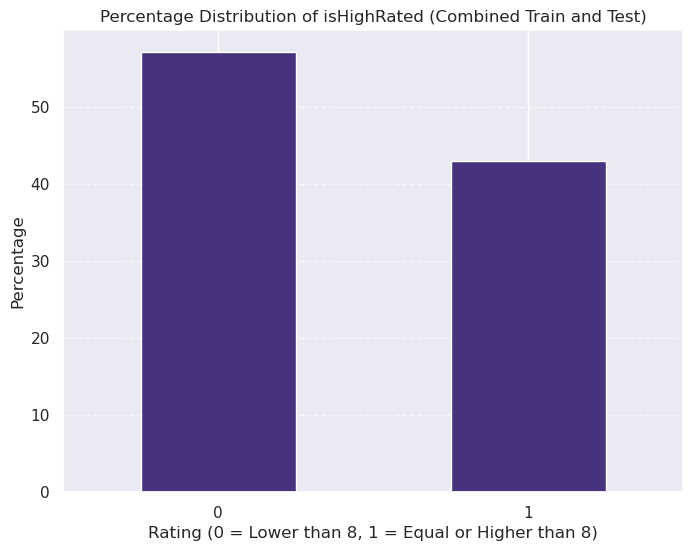

In [87]:
# Combine train and test datasets for analysis
combined_data = pd.concat([data_train, data_test])

# Calculate the percentage distribution of 'isHighRated'
percentages_combined = combined_data['isHighRated'].value_counts(normalize=True) * 100

# Print the percentages
print("Percentage distribution of 'isHighRated' (combined train and test):")
print(percentages_combined)

plt.figure(figsize=(8, 6))
percentages_combined.plot(kind='bar')
plt.title('Percentage Distribution of isHighRated (Combined Train and Test)')
plt.xlabel('Rating (0 = Lower than 8, 1 = Equal or Higher than 8)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [88]:
data_train['titleType'].unique()

array([2, 1, 0, 7, 8, 3])

## KNN

In [89]:
# List of columns to include for k-NN
# After a research, this selection of columns provided the best result
selected_columns = [
   'runtimeMinutes', "titleType", 'numRegions', 'startYear'
]

# Define features and target
X_train_knn = data_train[selected_columns]
y_train_knn = data_train['isHighRated']

X_test_knn = data_test[selected_columns]
y_test_knn = data_test['isHighRated']

X_train_knn.head()

,runtimeMinutes,titleType,numRegions,startYear
0,0.500000,2,0.693147,1995
1,1.500000,1,0.693147,1992
2,0.500000,0,0.693147,2021
3,0.566667,7,0.693147,1995
4,0.750000,2,0.693147,1995


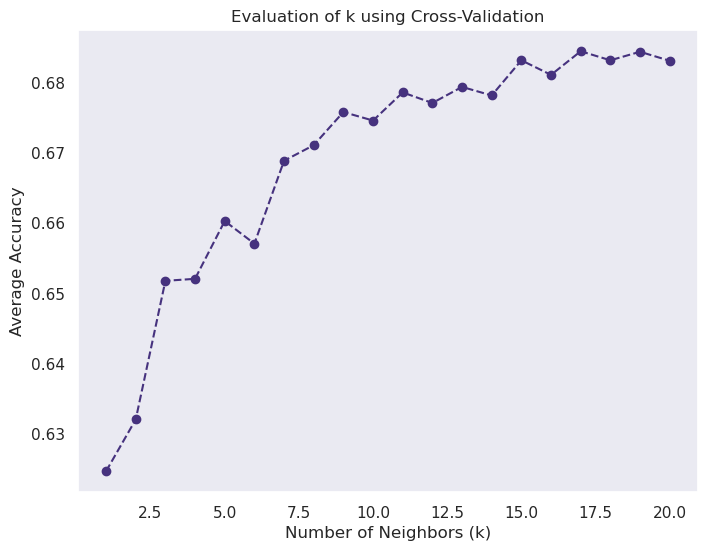

In [90]:
# Search for the best k value
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_knn, y_train_knn, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot to visualize k search
plt.figure(figsize=(8, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='--')
plt.title('Evaluation of k using Cross-Validation')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Average Accuracy')
plt.grid()
plt.show()

In [91]:
# Best k value
best_k = k_values[np.argmax(cv_scores)]
print(f"Best k value: {best_k}")

Best k value: 17


In [92]:
# Train the model with the best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_knn, y_train_knn)

y_pred = knn.predict(X_test_knn)

# Evaluate performance metrics
accuracy = accuracy_score(y_test_knn, y_pred)
precision = precision_score(y_test_knn, y_pred)
recall = recall_score(y_test_knn, y_pred)
f1 = f1_score(y_test_knn, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.69
Precision: 0.65
Recall: 0.64
F1 Score: 0.65


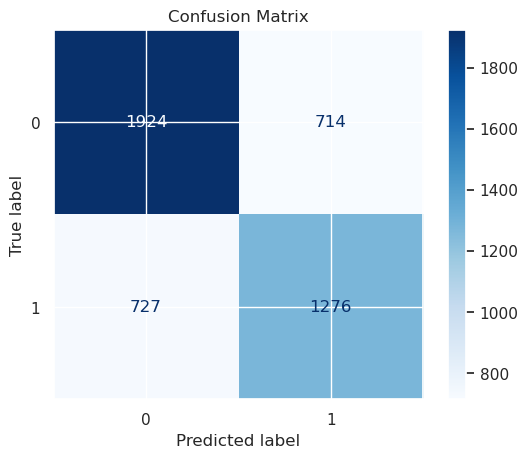

In [110]:
# Confusion matrix
cm = confusion_matrix(y_test_knn, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

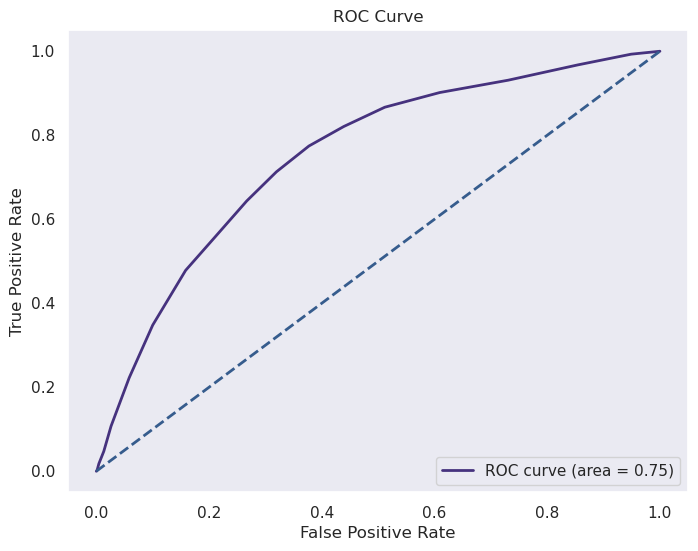

In [94]:
# ROC curve
y_test_binarized = label_binarize(y_test_knn, classes=[0, 1])
y_pred_proba = knn.predict_proba(X_test_knn)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_binarized, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

## Naive Bayes

In [95]:
# List of columns to include for Gaussian Naive Bayes
# After a research, this selection of columns provided the best result
selected_columns = ['runtimeMinutes', 'numVotes', 'totalCredits',
    'Adult', 'numRegions', 'startYear', 'titleType']

# Define features and target
X_train_gnb = data_train[selected_columns]
y_train_gnb = data_train['isHighRated']

X_test_gnb = data_test[selected_columns]
y_test_gnb = data_test['isHighRated']

In [96]:
# after having tried with Gaussian, Complement and Multinomial, Gaussian gave the best results
gnb = GaussianNB()
gnb.fit(X_train_gnb, y_train_gnb)

# Make predictions on the test set
y_pred = gnb.predict(X_test_gnb)

accuracy = accuracy_score(y_test_gnb, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_gnb, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test_gnb, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.6449

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.51      0.62      2638
           1       0.56      0.83      0.67      2003

    accuracy                           0.64      4641
   macro avg       0.68      0.67      0.64      4641
weighted avg       0.69      0.64      0.64      4641


Confusion Matrix:
[[1333 1305]
 [ 343 1660]]


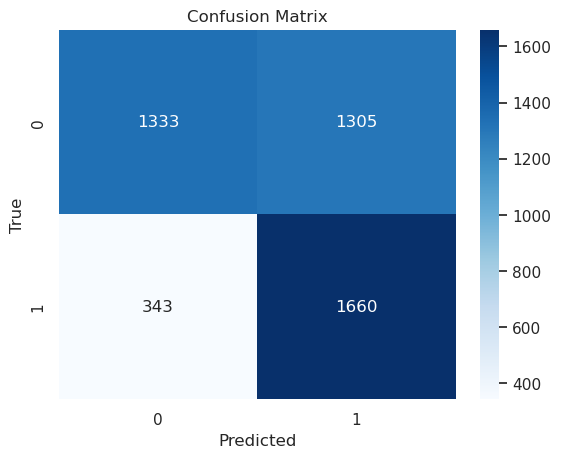

In [109]:
# Visualize Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', xticklabels=gnb.classes_, yticklabels=gnb.classes_, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

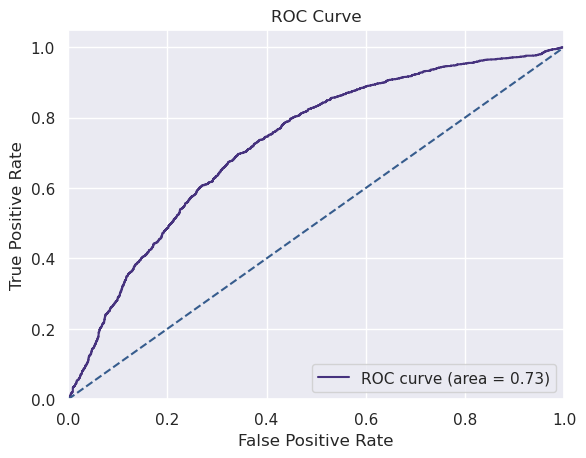

In [98]:
# ROC Curve
# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test_gnb, gnb.predict_proba(X_test_gnb)[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line for random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

## Decision Trees

In [99]:
# For Decision Trees, we'll use the not normalized datasets
not_normalized_data_train = pd.read_csv('data/output/02_data_understanding/clean_data_train.csv')
not_normalized_data_test = pd.read_csv('data/output/02_data_understanding/clean_data_test.csv')

# Supponendo che 'titleType' sia già stato etichettato tramite Label Encoding
not_normalized_data_train['titleType'] = not_normalized_data_train['titleType'].fillna(8.0)
not_normalized_data_test['titleType'] = not_normalized_data_test['titleType'].fillna(8.0)

# Creation of the new columns isHighRated, that will be used as target
not_normalized_data_train['isHighRated'] = (not_normalized_data_train['rating'] >= 8).astype(int)
not_normalized_data_test['isHighRated'] = (not_normalized_data_train['rating'] >= 8).astype(int)

# Define features and target
X_train_dt = not_normalized_data_train.drop(columns=['originalTitle', 'rating', 'isHighRated'])
y_train_dt = not_normalized_data_train['isHighRated']

X_test_dt = not_normalized_data_test.drop(columns=['originalTitle', 'rating', 'isHighRated'])
y_test_dt = not_normalized_data_test['isHighRated']

# Base model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_dt, y_train_dt)

# Predictions
y_pred = dt.predict(X_test_dt)

# Score
print("Accuracy:", accuracy_score(y_test_dt, y_pred))
print("Classification Report:\n", classification_report(y_test_dt, y_pred)) 

Accuracy: 0.508942038353803
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.57      0.57      2656
           1       0.43      0.43      0.43      1985

    accuracy                           0.51      4641
   macro avg       0.50      0.50      0.50      4641
weighted avg       0.51      0.51      0.51      4641



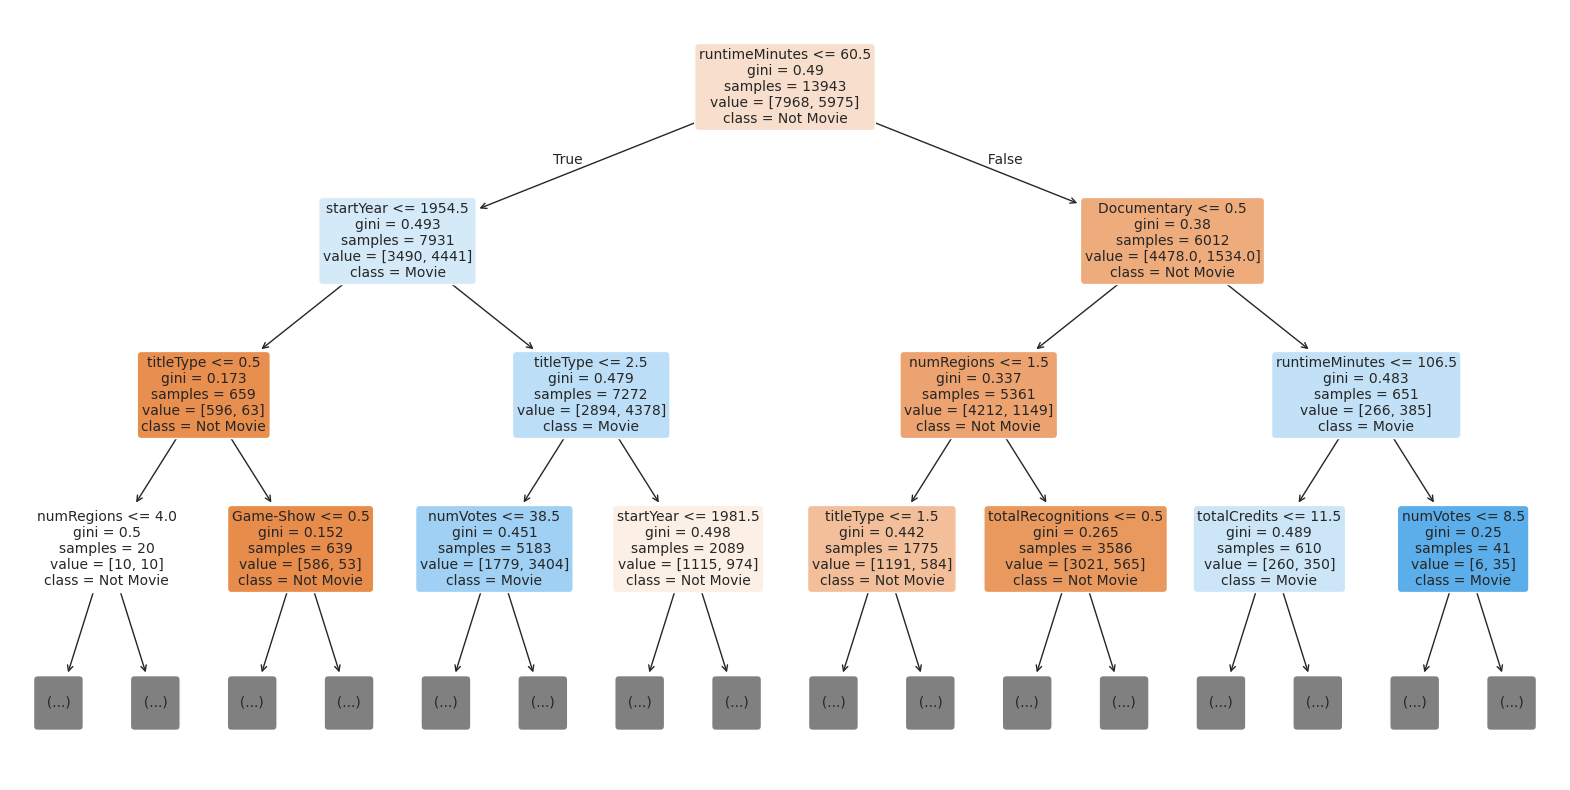

In [100]:
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X_train_dt.columns, class_names=['Not Movie', 'Movie'], max_depth=3, fontsize=10, filled=True, rounded=True)
plt.show()

In [101]:
# Hyperparameters
param_grid = {
    'criterion': ['gini', 'entropy'],         # Funzione di split
    'max_depth': [3, 5, 10, None],            # Profondità massima
    'min_samples_split': [2, 5, 10],          # Split minimo
    'min_samples_leaf': [1, 2, 4],            # Foglie minime
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1)

grid_search.fit(X_train_dt, y_train_dt)

# Migliori parametri e valutazione
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_test_dt)

print("\nClassification Report:")
print(classification_report(y_test_dt, y_pred_best))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.57      0.57      2656
           1       0.44      0.46      0.45      1985

    accuracy                           0.52      4641
   macro avg       0.51      0.51      0.51      4641
weighted avg       0.52      0.52      0.52      4641



In [102]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV


# Definisci i parametri con distribuzioni casuali
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': randint(2, 20),  # Valori casuali tra 2 e 20
    'min_samples_leaf': randint(1, 10)    # Valori casuali tra 1 e 10
}

# RandomizedSearchCV con 50 iterazioni
random_search = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                                   param_distributions=param_dist,
                                   n_iter=50,  # Numero di iterazioni
                                   cv=5,
                                   scoring='accuracy',
                                   random_state=42,
                                   verbose=1)

random_search.fit(X_train_dt, y_train_dt)

# Migliori parametri e valutazione
best_params = random_search.best_params_
print("Best Parameters:", best_params)

best_dt = random_search.best_estimator_
y_pred_best = best_dt.predict(X_test_dt)

print("\nClassification Report:")
print(classification_report(y_test_dt, y_pred_best))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 7, 'min_samples_split': 12}

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.57      0.57      2656
           1       0.44      0.45      0.44      1985

    accuracy                           0.52      4641
   macro avg       0.51      0.51      0.51      4641
weighted avg       0.52      0.52      0.52      4641



Optimized Accuracy: 0.5205774617539324
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.57      0.58      2656
           1       0.44      0.45      0.45      1985

    accuracy                           0.52      4641
   macro avg       0.51      0.51      0.51      4641
weighted avg       0.52      0.52      0.52      4641



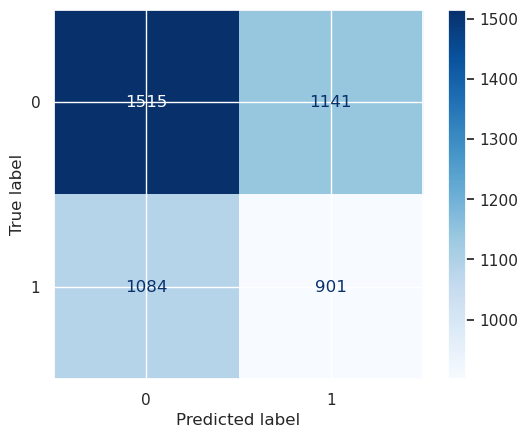

In [108]:
# Define the Decision Tree model with optimized parameters
dt_optimized = DecisionTreeClassifier(
    criterion='entropy',           # Split criterion (information gain)
    max_depth=10,                  # Maximum depth of the tree
    min_samples_leaf=2,            # Minimum number of samples required for a leaf node
    min_samples_split=4,           # Minimum number of samples required to split a node
    random_state=42,                # Ensures rxticklabelseproducibility of results
)

# Train the model on the training dataset
dt_optimized.fit(X_train_dt, y_train_dt)

# Make predictions on the test dataset
y_pred_optimized = dt_optimized.predict(X_test_dt)

# Evaluate the model's performance
print("Optimized Accuracy:", accuracy_score(y_test_dt, y_pred_optimized))  # Output overall accuracy
print("Classification Report:\n", classification_report(y_test_dt, y_pred_optimized))  # Detailed metrics

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test_dt, y_pred_optimized)

# Display the confusion matrix as a heatmap
ConfusionMatrixDisplay(conf_matrix, display_labels=dt_optimized.classes_).plot(cmap=plt.cm.Blues)

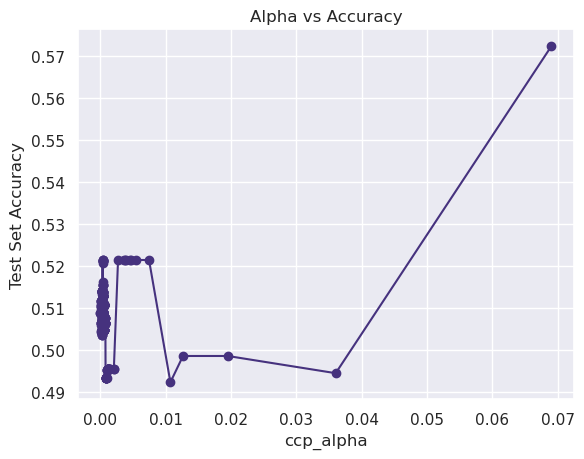

Best value of alpha: 0.06901879698590763
Its Accuracy: 0.57


In [104]:
# Tuning of Alpha
path = dt_optimized.cost_complexity_pruning_path(X_train_dt, y_train_dt)
alphas = path.ccp_alphas  # Serie di valori di α
scores = []

# Testare ogni valore di α
best_alpha = None
best_score = -1

for alpha in alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train_dt, y_train_dt)
    score = clf.score(X_test_dt, y_test_dt)
    scores.append(score)
    
    # Identificare il miglior alpha
    if score > best_score:
        best_score = score
        best_alpha = alpha

# Visualizzare l'accuratezza in funzione di α
plt.plot(alphas, scores, marker='o')
plt.xlabel('ccp_alpha')
plt.ylabel('Test Set Accuracy')
plt.title('Alpha vs Accuracy')
plt.show()

# Stampare il miglior valore di alpha e l'accuratezza corrispondente
print(f"Best value of alpha: {best_alpha}")
print(f"Its Accuracy: {best_score:.2f}")

# The value of alpha was inserted above


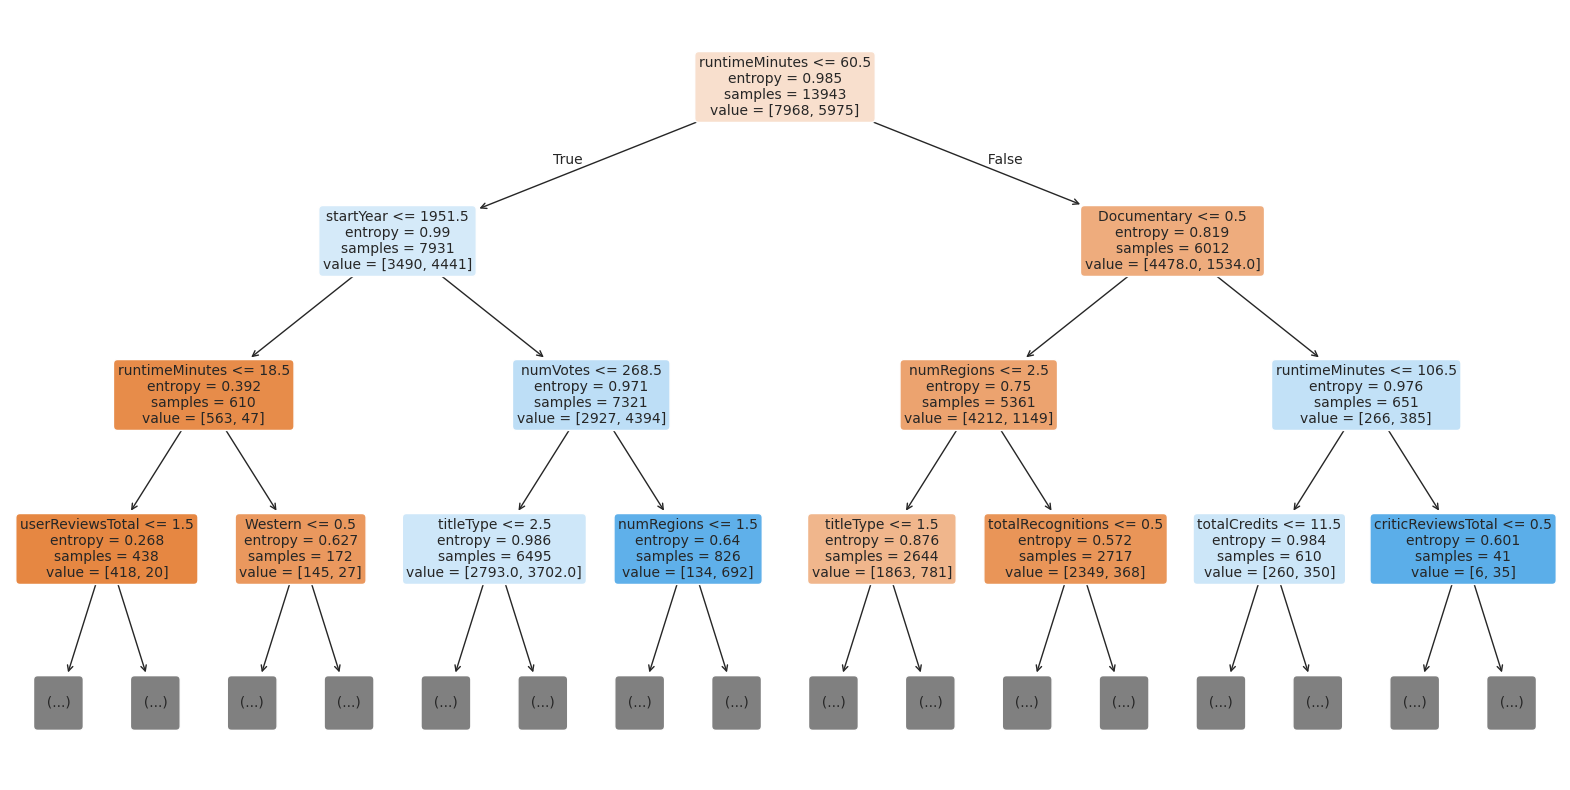

In [105]:
plt.figure(figsize=(20, 10))
plot_tree(dt_optimized, feature_names=X_train_dt.columns, filled=True, rounded=True, max_depth=3, fontsize=10)
plt.show()

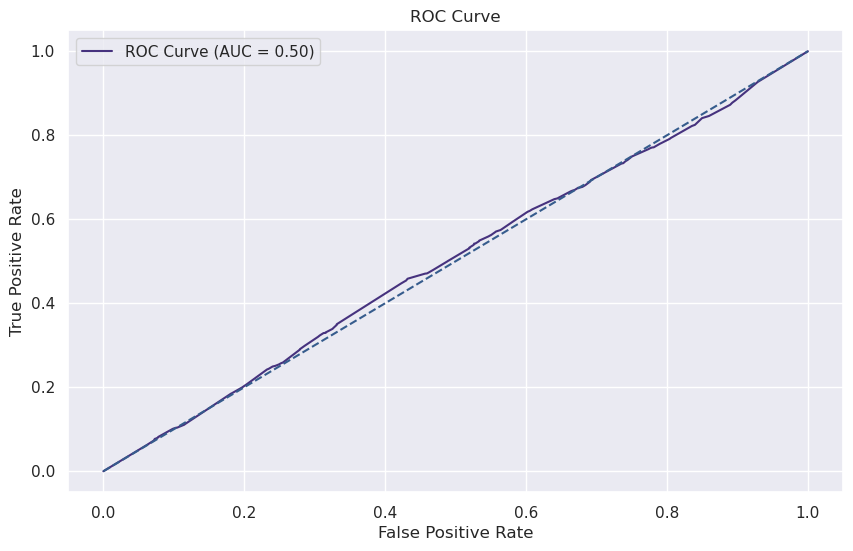

In [106]:
y_pred_proba = dt_optimized.predict_proba(X_test_dt)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_dt, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()